In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

orders_delivered = pd.read_csv('../data/orders_delivered_clean.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
translation = pd.read_csv('../data/product_category_name_translation.csv')

In [6]:
# seller_id 분석
orders_delivered_items = orders_delivered.merge(items[['order_id', 'seller_id']], on='order_id', how='left')

seller_processing = orders_delivered_items.groupby('seller_id')['seller_processing_time'].agg(['mean', 'count']).reset_index()
seller_processing.columns = ['seller_id', 'avg_processing_time', 'order_count']

seller_processing_filtered = seller_processing[seller_processing['order_count'] >= 10]
print(seller_processing_filtered.sort_values('avg_processing_time', ascending=False).head(10))
print(f"\n전체 seller 평균: {seller_processing_filtered['avg_processing_time'].mean():.1f}시간")
print(f"전체 seller 중앙값: {seller_processing_filtered['avg_processing_time'].median():.1f}시간")
print(f"분석 대상 seller 수: {len(seller_processing_filtered)}개")

                             seller_id  avg_processing_time  order_count
2740  ecccfa2bb93b34a3bf033cc5d1dcdc69           608.349965           16
1202  66e0557ecc2b4dbea057e93f215f68d8           430.219509           30
2746  ed859002ad59dbf8cf3602696a6c3000           393.889167           11
994   54965bbe3e4f07ae045b90b0b8541f52           387.224030           79
928   5058e8c1e82653974541e83690655b4a           368.887576           77
2045  b1b3948701c5c72445495bd161b83a4c           360.103095           14
1508  7fc87cc3e89b3d1d5cabdca32f8485aa           353.322679           14
1528  817f85dbb65aa3e70831d90fe75cdf89           345.077551           11
1306  6fd52c528dcb38be2eea044946b811f8           331.484537           84
1643  8bd0e3abda539b9479c4b44a691be1ec           330.616319           12

전체 seller 평균: 69.4시간
전체 seller 중앙값: 52.5시간
분석 대상 seller 수: 1329개


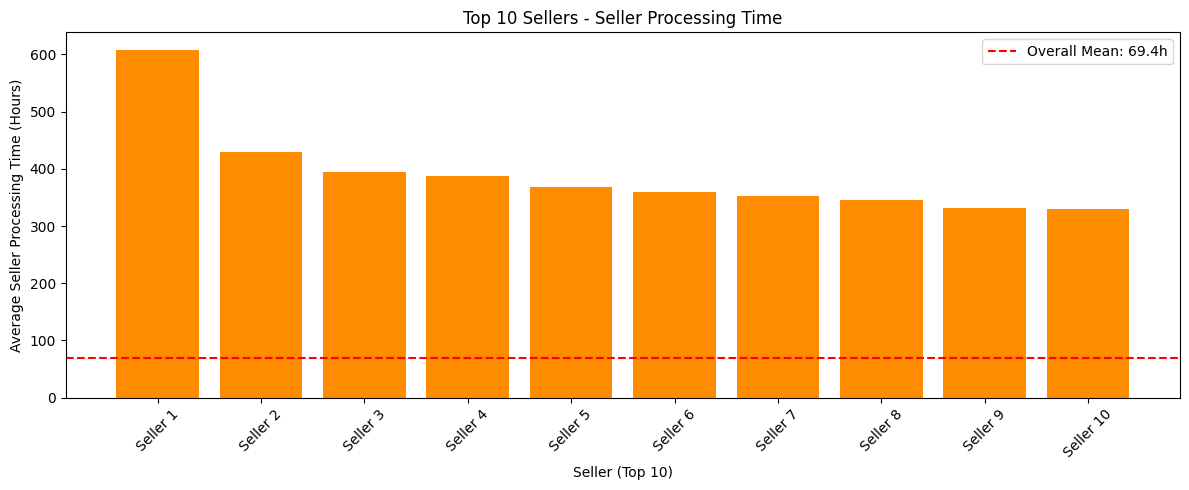

In [10]:
top10_sellers = seller_processing_filtered.sort_values('avg_processing_time', ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.bar(range(10), top10_sellers['avg_processing_time'], color='darkorange')
plt.axhline(y=seller_processing_filtered['avg_processing_time'].mean(), color='red', linestyle='--', label=f'Overall Mean: {seller_processing_filtered["avg_processing_time"].mean():.1f}h')
plt.xlabel('Seller (Top 10)')
plt.ylabel('Average Seller Processing Time (Hours)')
plt.title('Top 10 Sellers - Seller Processing Time')
plt.xticks(range(10), [f'Seller {i+1}' for i in range(10)], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
orders_sellers = orders_delivered.merge(items[['order_id', 'seller_id']], on='order_id', how='left')
orders_sellers = orders_sellers.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')

seller_state_delivery = orders_sellers.groupby('seller_state')['seller_processing_time'].mean().sort_values(ascending=False)
print(seller_state_delivery)

seller_state
MA    114.324457
RN     93.630541
MS     91.348634
AM     82.269630
PR     75.450341
RS     74.713937
PA     73.253681
CE     71.534338
BA     70.902296
SP     69.668412
MT     69.449963
MG     69.303089
PB     68.152685
SC     65.224151
DF     63.814753
RJ     60.831374
GO     54.824865
RO     52.322044
ES     50.050760
PE     43.480075
SE     38.637472
PI     36.502652
Name: seller_processing_time, dtype: float64


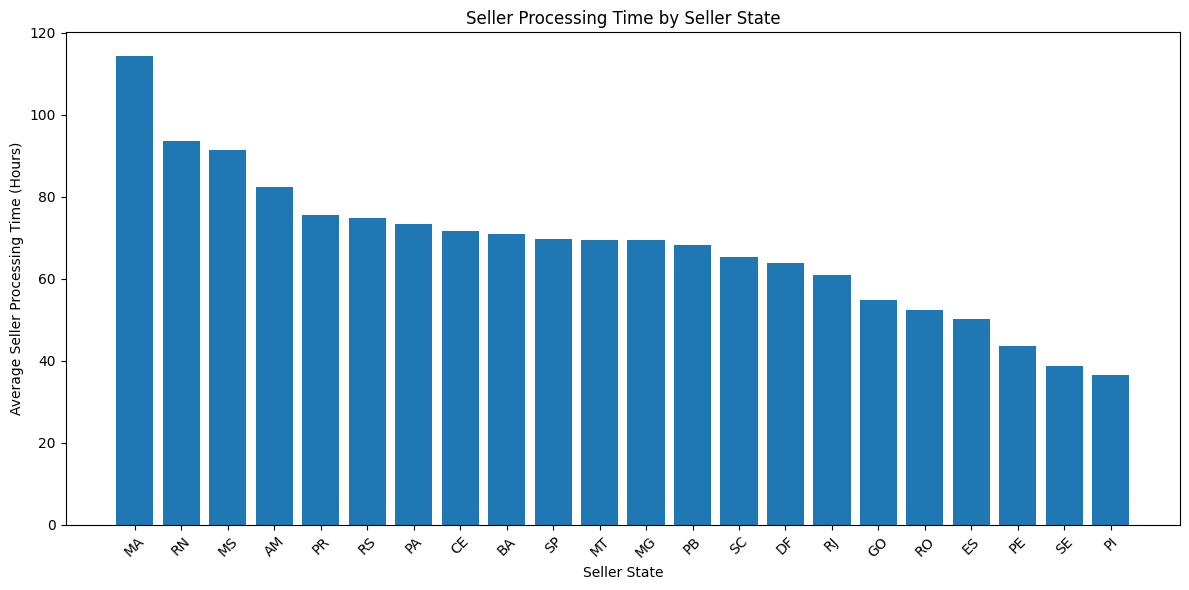

In [12]:
plt.figure(figsize=(12, 6))
plt.bar(seller_state_delivery.index, seller_state_delivery.values)
plt.xlabel('Seller State')
plt.ylabel('Average Seller Processing Time (Hours)')
plt.title('Seller Processing Time by Seller State')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
orders_sellers['order_approved_at'] = pd.to_datetime(orders_sellers['order_approved_at'])
orders_sellers['seller_month'] = orders_sellers['order_approved_at'].dt.month

monthly_seller = orders_sellers.groupby('seller_month')['seller_processing_time'].mean()
print(monthly_seller)

seller_month
1     78.045577
2     78.490987
3     72.570258
4     62.953793
5     58.174971
6     58.527364
7     64.907395
8     57.867089
9     68.685741
10    86.934787
11    88.275082
12    79.661743
Name: seller_processing_time, dtype: float64


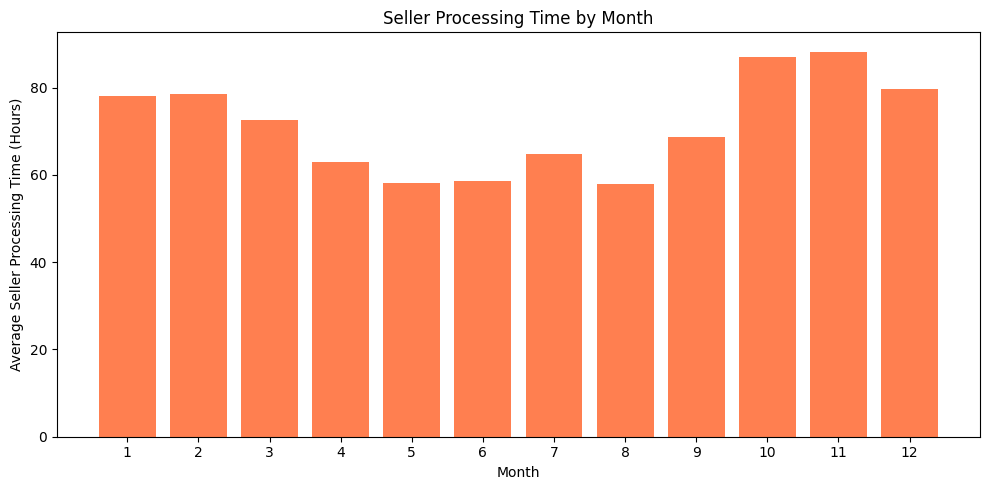

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(monthly_seller.index, monthly_seller.values, color='coral')
plt.xlabel('Month')
plt.ylabel('Average Seller Processing Time (Hours)')
plt.title('Seller Processing Time by Month')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [15]:
orders_sellers['seller_dayofweek'] = orders_sellers['order_approved_at'].dt.dayofweek

dayofweek_seller = orders_sellers.groupby('seller_dayofweek')['seller_processing_time'].mean()
print(dayofweek_seller)

seller_dayofweek
0    57.273144
1    57.882494
2    61.882043
3    70.637326
4    88.439264
5    91.840243
6    61.848047
Name: seller_processing_time, dtype: float64


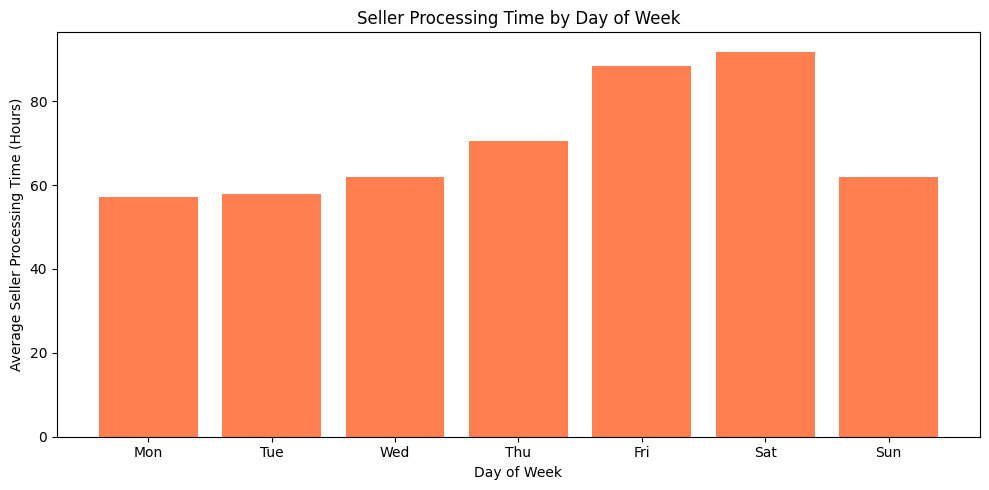

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(dayofweek_seller.index, dayofweek_seller.values, color='coral')
plt.xlabel('Day of Week')
plt.ylabel('Average Seller Processing Time (Hours)')
plt.title('Seller Processing Time by Day of Week')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.tight_layout()
plt.show()

In [17]:
orders_sellers_products = orders_sellers.merge(items[['order_id', 'product_id']], on='order_id', how='left')
orders_sellers_products = orders_sellers_products.merge(products[['product_id', 'product_category_name', 'product_weight_g']], on='product_id', how='left')
orders_sellers_products = orders_sellers_products.merge(translation, on='product_category_name', how='left')

print(orders_sellers_products.shape)

(151581, 21)


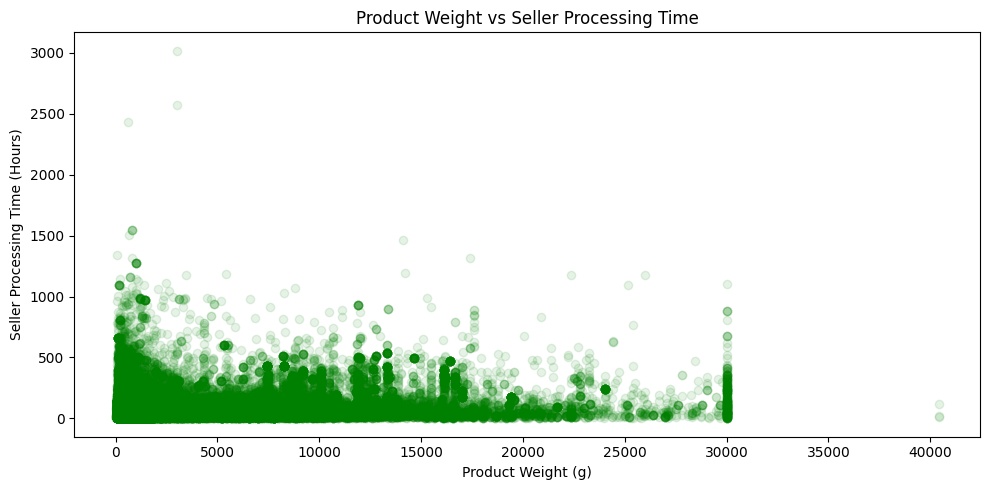

In [18]:
plt.figure(figsize=(10, 5))
plt.scatter(orders_sellers_products['product_weight_g'], orders_sellers_products['seller_processing_time'], alpha=0.1, color='green')
plt.xlabel('Product Weight (g)')
plt.ylabel('Seller Processing Time (Hours)')
plt.title('Product Weight vs Seller Processing Time')
plt.tight_layout()
plt.show()

In [19]:
from scipy import stats

clean = orders_sellers_products[['product_weight_g', 'seller_processing_time']].dropna()
corr, p_corr = stats.pearsonr(clean['product_weight_g'], clean['seller_processing_time'])
print(f"product_weight_g - 상관계수: {corr:.4f}, p-value: {p_corr:.4f}")

product_weight_g - 상관계수: 0.1842, p-value: 0.0000


In [20]:
category_seller = orders_sellers_products.groupby('product_category_name_english')['seller_processing_time'].mean().sort_values(ascending=False)

print(category_seller.head(10))
print()
print(category_seller.tail(10))

product_category_name_english
office_furniture                           266.537751
fashion_shoes                              123.624198
fashion_male_clothing                      122.885148
fashio_female_clothing                     109.778953
kitchen_dining_laundry_garden_furniture    103.191629
air_conditioning                           102.966356
home_appliances_2                          101.699716
market_place                                98.513029
fashion_underwear_beach                     93.945040
construction_tools_safety                   93.905401
Name: seller_processing_time, dtype: float64

product_category_name_english
cds_dvds_musicals            43.890463
party_supplies               42.185637
luggage_accessories          41.063950
fashion_sport                40.877332
food                         36.562723
arts_and_craftmanship        31.882901
cine_photo                   31.244367
fashion_childrens_clothes    31.239599
la_cuisine                   29.347454
sec

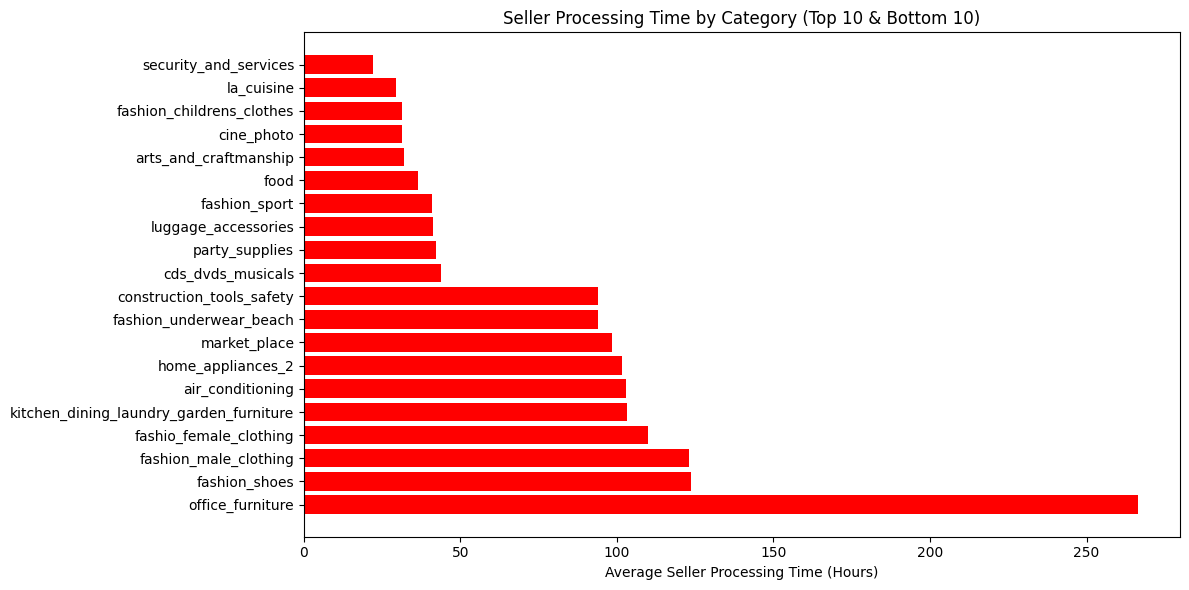

In [21]:
top10 = category_seller.head(10)
bottom10 = category_seller.tail(10)
combined = pd.concat([top10, bottom10])

plt.figure(figsize=(12, 6))
plt.barh(combined.index, combined.values, color='red')
plt.xlabel('Average Seller Processing Time (Hours)')
plt.title('Seller Processing Time by Category (Top 10 & Bottom 10)')
plt.tight_layout()
plt.show()

In [22]:
from scipy import stats

# seller_state ANOVA
groups_seller_state = [group['seller_processing_time'].values for name, group in orders_sellers.groupby('seller_state')]
f_seller_state, p_seller_state = stats.f_oneway(*groups_seller_state)
print(f"seller_state - F: {f_seller_state:.2f}, p-value: {p_seller_state:.4f}")

# seller_month ANOVA
groups_seller_month = [group['seller_processing_time'].values for name, group in orders_sellers.groupby('seller_month')]
f_seller_month, p_seller_month = stats.f_oneway(*groups_seller_month)
print(f"seller_month - F: {f_seller_month:.2f}, p-value: {p_seller_month:.4f}")

# seller_dayofweek ANOVA
groups_seller_day = [group['seller_processing_time'].values for name, group in orders_sellers.groupby('seller_dayofweek')]
f_seller_day, p_seller_day = stats.f_oneway(*groups_seller_day)
print(f"seller_dayofweek - F: {f_seller_day:.2f}, p-value: {p_seller_day:.4f}")

# product_weight 상관관계
clean = orders_sellers_products[['product_weight_g', 'seller_processing_time']].dropna()
corr, p_corr = stats.pearsonr(clean['product_weight_g'], clean['seller_processing_time'])
print(f"product_weight_g - 상관계수: {corr:.4f}, p-value: {p_corr:.4f}")

# category ANOVA
clean_cat = orders_sellers_products[['product_category_name_english', 'seller_processing_time']].dropna()
groups_seller_cat = [group['seller_processing_time'].values for name, group in clean_cat.groupby('product_category_name_english')]
f_seller_cat, p_seller_cat = stats.f_oneway(*groups_seller_cat)
print(f"product_category - F: {f_seller_cat:.2f}, p-value: {p_seller_cat:.4f}")

def eta_squared(groups):
    all_values = np.concatenate(groups)
    grand_mean = np.mean(all_values)
    ss_total = np.sum((all_values - grand_mean) ** 2)
    ss_between = np.sum([len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups])
    return ss_between / ss_total

print(f"\nseller_state η²: {eta_squared(groups_seller_state):.4f}")
print(f"seller_month η²: {eta_squared(groups_seller_month):.4f}")
print(f"seller_dayofweek η²: {eta_squared(groups_seller_day):.4f}")
print(f"product_category η²: {eta_squared(groups_seller_cat):.4f}")

seller_state - F: 14.63, p-value: 0.0000
seller_month - F: 151.75, p-value: 0.0000
seller_dayofweek - F: 454.25, p-value: 0.0000
product_weight_g - 상관계수: 0.1842, p-value: 0.0000
product_category - F: 312.45, p-value: 0.0000

seller_state η²: 0.0028
seller_month η²: 0.0151
seller_dayofweek η²: 0.0245
product_category η²: 0.1277


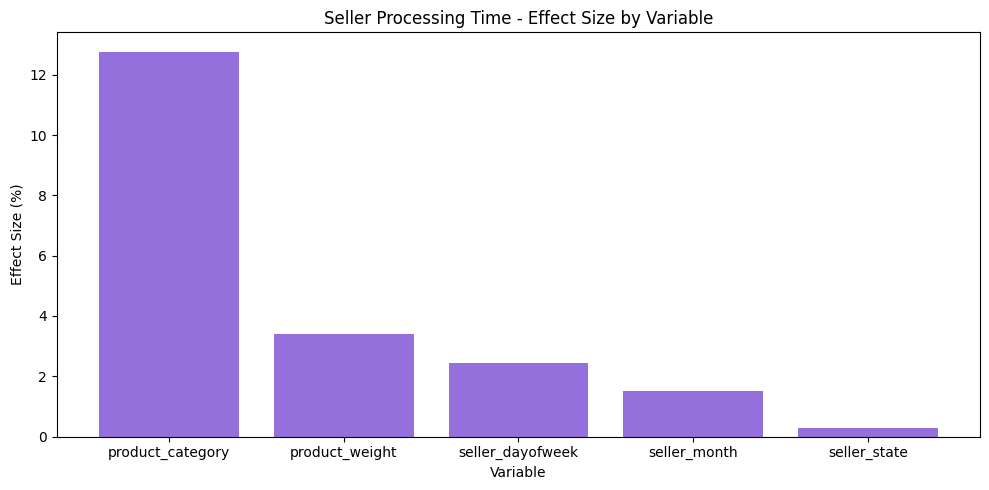

        variable  effect_size_pct
product_category        12.767945
  product_weight         3.393227
seller_dayofweek         2.448798
    seller_month         1.514213
    seller_state         0.282241


In [23]:
effect_sizes_seller = {
    'product_category': eta_squared(groups_seller_cat) * 100,
    'seller_dayofweek': eta_squared(groups_seller_day) * 100,
    'seller_month': eta_squared(groups_seller_month) * 100,
    'product_weight': (corr ** 2) * 100,
    'seller_state': eta_squared(groups_seller_state) * 100
}

effect_df_seller = pd.DataFrame(list(effect_sizes_seller.items()), columns=['variable', 'effect_size_pct'])
effect_df_seller = effect_df_seller.sort_values('effect_size_pct', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(effect_df_seller['variable'], effect_df_seller['effect_size_pct'], color='mediumpurple')
plt.xlabel('Variable')
plt.ylabel('Effect Size (%)')
plt.title('Seller Processing Time - Effect Size by Variable')
plt.tight_layout()
plt.show()

print(effect_df_seller.to_string(index=False))

In [24]:
orders_sellers_products.groupby('product_category_name_english')['seller_processing_time'].agg(['count', 'mean']).sort_values('mean', ascending=False).head(15)

,count,mean
product_category_name_english,,
office_furniture,3322,266.537751
fashion_shoes,317,123.624198
fashion_male_clothing,171,122.885148
fashio_female_clothing,82,109.778953
kitchen_dining_laundry_garden_furniture,356,103.191629
air_conditioning,413,102.966356
home_appliances_2,235,101.699716
market_place,441,98.513029
fashion_underwear_beach,159,93.945040
